## FSPL

Assuming reflection and polarized-matched antennas, the *Friis Transmission Equation* can be expressed in logarithmic form as
$$
\begin{align}
P_{r,\mathrm{dBm}} &= P_{t,\mathrm{dBm}} + G_{t,dB} + G_{r,dB} + 20\log_{10}\left(\frac{\lambda}{4\pi R}
\right) \\
&\approx P_{t,\mathrm{dBm}} + G_{t,\mathrm{dBi}} + G_{r,\mathrm{dBi}} - 20\log_{10}(d) - 20\log_{10}(f) + 147.55
\end{align}
$$

Where the last term in (1) refers to the *free-space path loss factor* and accounts for the spherical spreading of energy by the antenna


## Log-Normal Shadowing

31.220394503529832


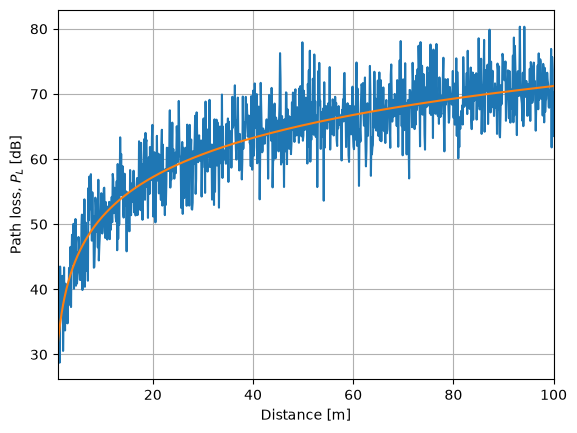

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

FREQUENCY = 868e6 # Hz
STD_SHADOWING = 4 # From ETSI TR 138 901, UMi street canyon

class LogDistance:
    """Calculates the log-distance path loss in dB"""
    def __init__(self, freq: float, rx_ant_gain=0.0, tx_ant_gain=0.0, ref_dist=1.0, loss_exponent=2.0):
        self.f = freq # Hz
        self.d0 = ref_dist # m
        self.gamma = loss_exponent
        self.K = (
            - rx_ant_gain 
            - tx_ant_gain 
            + 20 * np.log10(freq) 
            + 20 * np.log10(ref_dist) 
            - 147.55 )

    def __call__(self, dist):
        return self.K + 10 * self.gamma * np.log10(dist / self.d0) 

class LogShadow:
    """Calculates the log-normal shadowing path loss in dB"""
    def __init__(self, log_dist: LogDistance, std: float):
        self.L = log_dist
        self.sigma = max(0, std)
        
    def __call__(self, dist):
        dist = np.asarray(dist)
        return self.L(dist) + np.random.normal(0, self.sigma, size=dist.shape)



# Monte Carlo simulation for
def coverage_radius

log_dist = LogDistance(FREQUENCY)

log_shadow = LogShadow(log_dist, STD_SHADOWING)
distances = np.linspace(1, 100, 1000)

plt.plot(distances, log_shadow(distances))
plt.plot(distances, log_dist(distances))
plt.xlabel("Distance [m]")
plt.ylabel("Path loss, $P_L$ [dB]")
plt.grid(True, which="both")
plt.xlim(min(distances), max(distances))
plt.show()
